<a href="https://colab.research.google.com/github/Zinc-zn/MachineLearning2026/blob/main/JS04_Tugas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#(Deskripsi Dataset)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Memuat dataset
df = pd.read_csv('insurance.csv')

print("--- Penjelasan Singkat Dataset ---")
print("Dataset ini berisi informasi tagihan biaya medis personal dari asuransi kesehatan.")
print("Deskripsi Variabel:")
print("1. age (numerik): Usia penerima manfaat utama.")
print("2. sex (kategorikal): Jenis kelamin (female/male).")
print("3. bmi (numerik): Body Mass Index, indikator berat badan ideal.")
print("4. children (numerik): Jumlah anak/tanggungan yang dicover asuransi.")
print("5. smoker (kategorikal): Status perokok (yes/no).")
print("6. region (kategorikal): Wilayah tempat tinggal di AS (northeast/southeast/southwest/northwest).")
print("7. charges (numerik): Biaya medis individu yang ditagihkan (Variabel Target).\n")

print("Info Dataset:")
df.info()

print("\n5 Baris Pertama Data:")
display(df.head())

--- Penjelasan Singkat Dataset ---
Dataset ini berisi informasi tagihan biaya medis personal dari asuransi kesehatan.
Deskripsi Variabel:
1. age (numerik): Usia penerima manfaat utama.
2. sex (kategorikal): Jenis kelamin (female/male).
3. bmi (numerik): Body Mass Index, indikator berat badan ideal.
4. children (numerik): Jumlah anak/tanggungan yang dicover asuransi.
5. smoker (kategorikal): Status perokok (yes/no).
6. region (kategorikal): Wilayah tempat tinggal di AS (northeast/southeast/southwest/northwest).
7. charges (numerik): Biaya medis individu yang ditagihkan (Variabel Target).

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region 

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


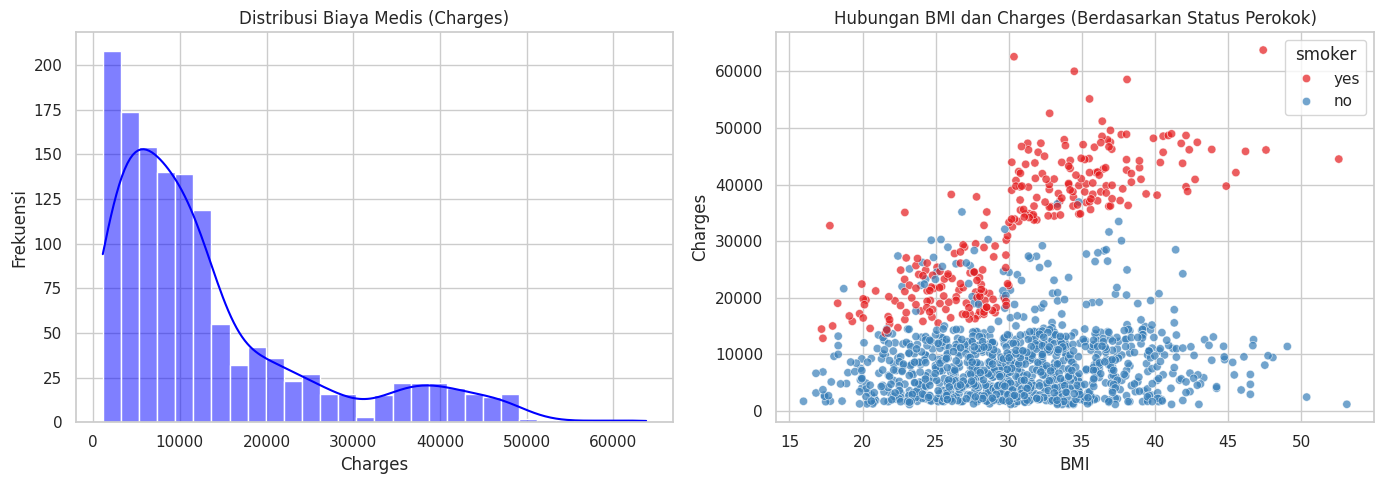


Analisis Visualisasi:
- Distribusi 'charges' condong ke kanan (right-skewed). Mayoritas tagihan berada di rentang bawah (< 15.000).
- Scatter plot menunjukkan status perokok ('smoker = yes') memicu lonjakan tagihan medis yang sangat signifikan, terutama ketika BMI meningkat.


In [3]:
# (Visualisasi Data)
# Mengatur gaya plot
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 5))

# Visualisasi 1: Distribusi Biaya (Target)
plt.subplot(1, 2, 1)
sns.histplot(df['charges'], kde=True, color='blue')
plt.title('Distribusi Biaya Medis (Charges)')
plt.xlabel('Charges')
plt.ylabel('Frekuensi')

# Visualisasi 2: Scatter plot BMI vs Charges dibedakan oleh status perokok
plt.subplot(1, 2, 2)
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df, palette='Set1', alpha=0.7)
plt.title('Hubungan BMI dan Charges (Berdasarkan Status Perokok)')
plt.xlabel('BMI')
plt.ylabel('Charges')

plt.tight_layout()
plt.show()

print("\nAnalisis Visualisasi:")
print("- Distribusi 'charges' condong ke kanan (right-skewed). Mayoritas tagihan berada di rentang bawah (< 15.000).")
print("- Scatter plot menunjukkan status perokok ('smoker = yes') memicu lonjakan tagihan medis yang sangat signifikan, terutama ketika BMI meningkat.")

In [4]:
# (Identifikasi Variabel & Encoding)
# Preprocessing: Encoding variabel kategorikal (sex, smoker, region)
# Menggunakan One-Hot Encoding agar bisa diproses oleh algoritma Machine Learning
df_encoded = pd.get_dummies(df, drop_first=True)

# 1. Identifikasi variabel bebas (fitur) dan variabel target
# Target = 'charges', Fitur = sisanya
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

print("Tugas 1 Selesai: Fitur (X) dan Target (y) telah diidentifikasi dan data kategorikal telah di-encode.\n")
print("Fitur (X) - 5 baris pertama:")
display(X.head())
print("\nTarget (y) - 5 baris pertama:")
display(y.head())

Tugas 1 Selesai: Fitur (X) dan Target (y) telah diidentifikasi dan data kategorikal telah di-encode.

Fitur (X) - 5 baris pertama:


,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,False,True,False,False,True
1,18,33.770,1,True,False,False,True,False
2,28,33.000,3,True,False,False,True,False
3,33,22.705,0,True,False,True,False,False
4,32,28.880,0,True,False,True,False,False



Target (y) - 5 baris pertama:


,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520


In [5]:
#(Pembagian Dataset)
from sklearn.model_selection import train_test_split

# 2. Bagi dataset menjadi data latih (train) dan data uji (test) dengan proporsi 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Tugas 2 Selesai: Data berhasil dibagi.")
print(f"Dimensi X_train (Data Latih) : {X_train.shape}")
print(f"Dimensi X_test (Data Uji)   : {X_test.shape}")

Tugas 2 Selesai: Data berhasil dibagi.
Dimensi X_train (Data Latih) : (1070, 8)
Dimensi X_test (Data Uji)   : (268, 8)


In [6]:
#(Feature Scaling)
from sklearn.preprocessing import StandardScaler

# 3. Lakukan feature scaling
# Hal ini krusial terutama untuk algoritma jarak seperti SVR, dan membantu konvergensi pada regresi
scaler = StandardScaler()

# Fit pada data latih, transform pada data latih dan uji untuk menghindari data leakage
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Tugas 3 Selesai: Feature scaling pada X_train dan X_test menggunakan StandardScaler berhasil dilakukan.")

Tugas 3 Selesai: Feature scaling pada X_train dan X_test menggunakan StandardScaler berhasil dilakukan.


In [7]:
# (Multiple Linear Regression)
from sklearn.linear_model import LinearRegression

# 4. Buat model multiple linear regression
mlr_model = LinearRegression()

# 5. Latih model dan lakukan prediksi
mlr_model.fit(X_train_scaled, y_train)
y_pred_mlr = mlr_model.predict(X_test_scaled)

print("Tugas 4 & 5 Selesai: Model Multiple Linear Regression telah dilatih dan prediksi telah dieksekusi pada data uji.")

Tugas 4 & 5 Selesai: Model Multiple Linear Regression telah dilatih dan prediksi telah dieksekusi pada data uji.


In [8]:
# (Evaluasi Multiple Linear Regression)
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 6. Evaluasi model
r2_mlr = r2_score(y_test, y_pred_mlr)
mse_mlr = mean_squared_error(y_test, y_pred_mlr)
mae_mlr = mean_absolute_error(y_test, y_pred_mlr)

print("--- Hasil Evaluasi Multiple Linear Regression ---")
print(f"R-squared : {r2_mlr:.4f}")
print(f"MSE       : {mse_mlr:.4f}")
print(f"MAE       : {mae_mlr:.4f}")

print("\nAnalisis (Catatan 3 - Bagian MLR):")
print(f"- R-squared bernilai {r2_mlr:.4f}, artinya model mampu menjelaskan {r2_mlr*100:.2f}% dari total variansi biaya medis.")
print(f"- MAE sebesar {mae_mlr:.2f} berarti secara rata-rata, prediksi model meleset sekitar {mae_mlr:.2f} dolar dari tagihan aslinya.")

--- Hasil Evaluasi Multiple Linear Regression ---
R-squared : 0.7836
MSE       : 33596915.8514
MAE       : 4181.1945

Analisis (Catatan 3 - Bagian MLR):
- R-squared bernilai 0.7836, artinya model mampu menjelaskan 78.36% dari total variansi biaya medis.
- MAE sebesar 4181.19 berarti secara rata-rata, prediksi model meleset sekitar 4181.19 dolar dari tagihan aslinya.


In [9]:
#(SVR & Hyperparameter Tuning)
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

# Menentukan parameter yang akan diuji
param_grid = {
    'kernel': ['linear', 'rbf'],
    'C': [1000, 5000, 10000, 15000],
    'gamma': ['scale', 'auto', 0.1, 0.01]
}

print("Sedang melakukan Hyperparameter Tuning pada SVR (harap tunggu beberapa saat)...")
# Membuat dan melatih GridSearchCV
svr = SVR()
grid_search = GridSearchCV(svr, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train)

# Ekstraksi model terbaik
best_svr = grid_search.best_estimator_
print(f"\nParameter Terbaik Ditemukan: {grid_search.best_params_}")

# Prediksi menggunakan model SVR terbaik
y_pred_svr = best_svr.predict(X_test_scaled)

# Evaluasi SVR
r2_svr = r2_score(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)

print("\n--- Hasil Evaluasi Support Vector Regression (SVR) ---")
print(f"R-squared : {r2_svr:.4f}")
print(f"MSE       : {mse_svr:.4f}")
print(f"MAE       : {mae_svr:.4f}")

print("\nAnalisis Keseluruhan (Catatan 3 - Perbandingan):")
if r2_svr > r2_mlr:
    print("- SVR dengan Hyperparameter Tuning memberikan hasil R-squared yang LEBIH BAIK dibandingkan Multiple Linear Regression.")
    print("- Hal ini membuktikan bahwa hubungan antar variabel dalam dataset ini (terutama interaksi BMI dan perokok) memiliki pola non-linear kompleks yang ditangkap lebih baik oleh parameter C dan kernel spesifik (seperti RBF) pada SVR.")
else:
    print("- Multiple Linear Regression memberikan hasil yang lebih kompetitif. Kemungkinan batas linier sudah cukup untuk memodelkan data ini secara general, atau grid parameter SVR bisa diperluas lagi.")

Sedang melakukan Hyperparameter Tuning pada SVR (harap tunggu beberapa saat)...
Fitting 5 folds for each of 32 candidates, totalling 160 fits

Parameter Terbaik Ditemukan: {'C': 15000, 'gamma': 0.1, 'kernel': 'rbf'}

--- Hasil Evaluasi Support Vector Regression (SVR) ---
R-squared : 0.8561
MSE       : 22344599.5070
MAE       : 1774.8547

Analisis Keseluruhan (Catatan 3 - Perbandingan):
- SVR dengan Hyperparameter Tuning memberikan hasil R-squared yang LEBIH BAIK dibandingkan Multiple Linear Regression.
- Hal ini membuktikan bahwa hubungan antar variabel dalam dataset ini (terutama interaksi BMI dan perokok) memiliki pola non-linear kompleks yang ditangkap lebih baik oleh parameter C dan kernel spesifik (seperti RBF) pada SVR.
